Total Successfully Converged Galaxies: 174
WILL Derived Median Mass-to-Light Ratio: 0.471 M_sun/L_sun
WILL Derived Mean Mass-to-Light Ratio: 0.615 M_sun/L_sun


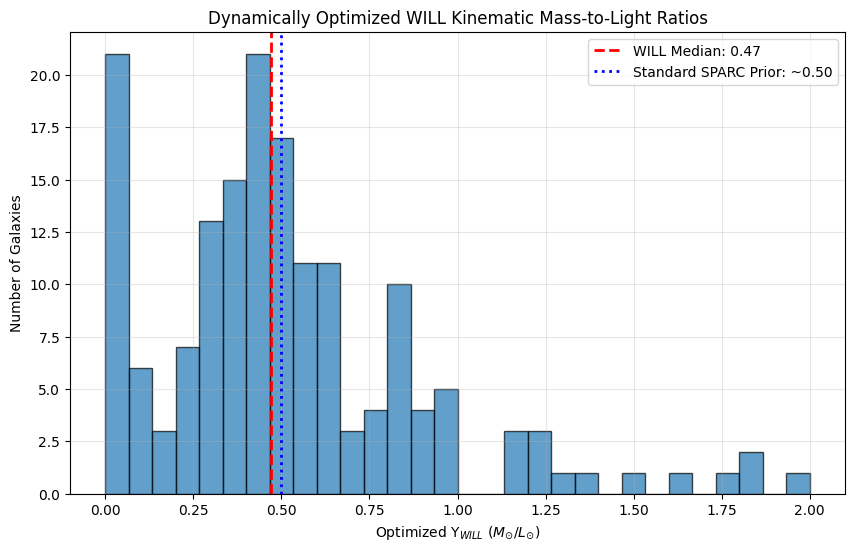

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Define Universal Constants
c = 299792458           # m/s
H0_km_s_Mpc = 68.15
H0_s = H0_km_s_Mpc * 1000 / 3.086e22  # 1/s
a_k = (c * H0_s) / (3 * np.pi)        # WILL Machian invariant (~7.02e-11 m/s^2)
kpc_to_m = 3.086e19     # Conversion factor

# 2. Load the Remote SPARC Datasets
url_t2 = "https://raw.githubusercontent.com/AntonRize/WILL/refs/heads/main/SPARC%20DATA/table2.dat"

# Parse table2.dat fixed-width columns based on SPARC documentation
colspecs_t2 = [(0, 11), (12, 18), (19, 25), (26, 32), (33, 38), (39, 45), (46, 52), (53, 59)]
names_t2 = ['Name', 'Dist', 'Rad', 'Vobs', 'e_Vobs', 'Vgas', 'Vdisk', 'Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')

# Clean missing data (some galaxies lack bulges; fill with 0)
df2['Vbulge'] = df2['Vbulge'].fillna(0)
df2 = df2.dropna(subset=['Rad', 'Vobs', 'e_Vobs', 'Vgas', 'Vdisk'])

# Ensure e_Vobs > 0 to prevent division by zero in chi-squared
df2 = df2[df2['e_Vobs'] > 0]

# 3. Define the WILL Kinematic Core
def calc_v_theory(upsilon, r_kpc, v_gas_km, v_disk_km, v_bulge_km):
    r_m = r_kpc * kpc_to_m

    # SPARC kinematic velocities. Vgas can be negative (representing net mass deficit).
    # We use V * |V| to strictly preserve the force vector direction.
    v_gas_sq = v_gas_km * np.abs(v_gas_km) * 1e6
    v_disk_sq = (v_disk_km**2) * 1e6
    v_bulge_sq = (v_bulge_km**2) * 1e6

    # Compute the purely Newtonian baryonic capacity
    v_bar_sq = v_gas_sq + upsilon * (v_disk_sq + v_bulge_sq)

    # Ensure local capacity does not fall below zero prior to resonance bridge
    v_bar_sq = np.maximum(v_bar_sq, 0)

    # The WILL Resonant Bridge Equation
    v_theory_sq = v_bar_sq + np.sqrt(v_bar_sq * a_k * r_m)
    return np.sqrt(v_theory_sq)

def objective_function(upsilon, r_kpc, v_obs_km, e_vobs_km, v_gas_km, v_disk_km, v_bulge_km):
    v_theory_ms = calc_v_theory(upsilon[0], r_kpc, v_gas_km, v_disk_km, v_bulge_km)

    # Calculate error-weighted chi-squared residuals
    residuals = (v_obs_km * 1000 - v_theory_ms) / (e_vobs_km * 1000)
    return np.sum(residuals**2)

# 4. Execute the Dynamic Optimization Loop
results = []
galaxies = df2['Name'].unique()

for gal in galaxies:
    gal_data = df2[df2['Name'] == gal]

    # Skip galaxies with insufficient radial data points for a valid fit
    if len(gal_data) < 3:
        continue

    # Extract arrays
    r = gal_data['Rad'].values
    v_o = gal_data['Vobs'].values
    e_o = gal_data['e_Vobs'].values
    v_g = gal_data['Vgas'].values
    v_d = gal_data['Vdisk'].values
    v_b = gal_data['Vbulge'].values

    # Initial guess strictly neutral (1.0)
    # Bounds set to strictly positive, up to 3.0 to catch heavily obscured systems
    res = minimize(
        objective_function,
        x0=[1.0],
        args=(r, v_o, e_o, v_g, v_d, v_b),
        bounds=[(0.01, 3.0)],
        method='L-BFGS-B'
    )

    if res.success:
        results.append({'Name': gal, 'Upsilon_WILL': res.x[0], 'Chi_Sq': res.fun, 'N_Points': len(gal_data)})

df_results = pd.DataFrame(results)

# 5. Statistical Yield and Falsification Output
median_upsilon = df_results['Upsilon_WILL'].median()
mean_upsilon = df_results['Upsilon_WILL'].mean()

print(f"Total Successfully Converged Galaxies: {len(df_results)}")
print(f"WILL Derived Median Mass-to-Light Ratio: {median_upsilon:.3f} M_sun/L_sun")
print(f"WILL Derived Mean Mass-to-Light Ratio: {mean_upsilon:.3f} M_sun/L_sun")

# 6. Visualization
plt.figure(figsize=(10, 6))
plt.hist(df_results['Upsilon_WILL'], bins=30, range=(0, 2), edgecolor='black', alpha=0.7)
plt.axvline(median_upsilon, color='red', linestyle='dashed', linewidth=2, label=f'WILL Median: {median_upsilon:.2f}')
plt.axvline(0.5, color='blue', linestyle='dotted', linewidth=2, label='Standard SPARC Prior: ~0.50')

plt.title("Dynamically Optimized WILL Kinematic Mass-to-Light Ratios")
plt.xlabel("Optimized $\\Upsilon_{WILL}$ ($M_{\\odot}/L_{\\odot}$)")
plt.ylabel("Number of Galaxies")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Total Converged Galaxies: 174
Median Delta (D_WILL / D_SPARC): 1.010


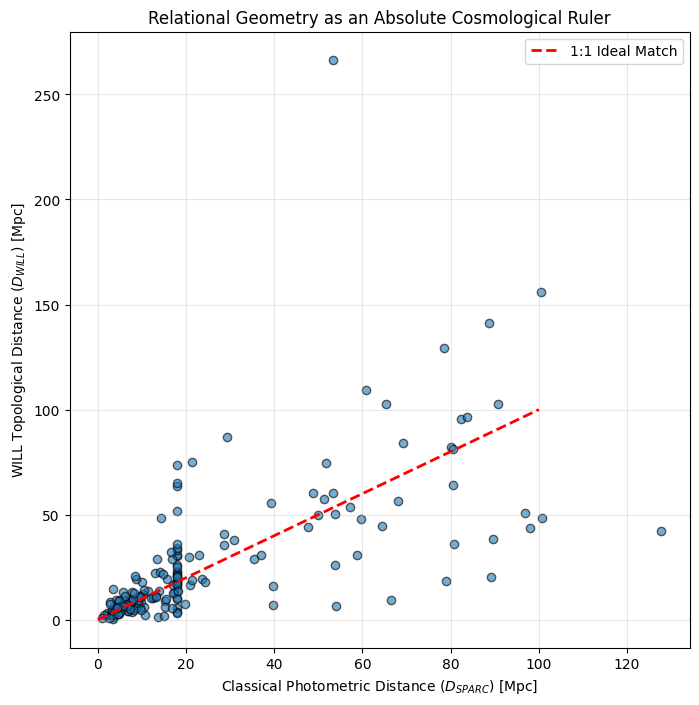

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Define Universal Constants
c = 299792458           # m/s
H0_km_s_Mpc = 68.15
H0_s = H0_km_s_Mpc * 1000 / 3.086e22
a_k = (c * H0_s) / (3 * np.pi)
kpc_to_m = 3.086e19

# 2. Load the Remote SPARC Datasets
url_t2 = "https://raw.githubusercontent.com/AntonRize/WILL/refs/heads/main/SPARC%20DATA/table2.dat"
colspecs_t2 = [(0, 11), (12, 18), (19, 25), (26, 32), (33, 38), (39, 45), (46, 52), (53, 59)]
names_t2 = ['Name', 'Dist_SPARC', 'Rad', 'Vobs', 'e_Vobs', 'Vgas', 'Vdisk', 'Vbulge']

df2 = pd.read_fwf(url_t2, colspecs=colspecs_t2, names=names_t2, comment='#')
df2['Vbulge'] = df2['Vbulge'].fillna(0)
df2 = df2.dropna(subset=['Rad', 'Vobs', 'e_Vobs', 'Vgas', 'Vdisk'])
df2 = df2[df2['e_Vobs'] > 0]

# 3. Define the Decoupled WILL Dual-Optimization Core
def objective_function(params, r_kpc_sparc, v_obs_km, e_vobs_km, v_gas_km, v_disk_km, v_bulge_km):
    upsilon, delta = params  # delta = D_WILL / D_SPARC

    r_m_sparc = r_kpc_sparc * kpc_to_m
    v_gas_sq = v_gas_km * np.abs(v_gas_km) * 1e6
    v_disk_sq = (v_disk_km**2) * 1e6
    v_bulge_sq = (v_bulge_km**2) * 1e6

    # 1. Morphological Shape Component
    v_shape_sq = v_gas_sq + upsilon * (v_disk_sq + v_bulge_sq)
    v_shape_sq = np.maximum(v_shape_sq, 0)

    # 2. The Decoupled Resonant Bridge
    # V_theory^2 = delta * [ V_shape^2 + sqrt(V_shape^2 * a_k * R_SPARC) ]
    bracket_term = v_shape_sq + np.sqrt(v_shape_sq * a_k * r_m_sparc)
    v_theory_sq = delta * bracket_term

    v_theory_ms = np.sqrt(np.maximum(v_theory_sq, 0))

    # Minimize error-weighted residuals
    residuals = (v_obs_km * 1000 - v_theory_ms) / (e_vobs_km * 1000)
    return np.sum(residuals**2)

# 4. Execute Dual-Optimization Loop
results = []
galaxies = df2['Name'].unique()

for gal in galaxies:
    gal_data = df2[df2['Name'] == gal]
    if len(gal_data) < 4:  # Need more data points for a 2-parameter fit
        continue

    r = gal_data['Rad'].values
    v_o = gal_data['Vobs'].values
    e_o = gal_data['e_Vobs'].values
    v_g = gal_data['Vgas'].values
    v_d = gal_data['Vdisk'].values
    v_b = gal_data['Vbulge'].values
    d_sparc = gal_data['Dist_SPARC'].values[0]

    # Initial guesses: Upsilon = 0.5, Delta = 1.0 (Assume SPARC distance is close)
    res = minimize(
        objective_function,
        x0=[0.5, 1.0],
        args=(r, v_o, e_o, v_g, v_d, v_b),
        bounds=[(0.01, 3.0), (0.1, 5.0)], # Delta bounded to prevent runaway scaling
        method='L-BFGS-B'
    )

    if res.success:
        upsilon_opt, delta_opt = res.x
        d_will = d_sparc * delta_opt
        results.append({
            'Name': gal,
            'Upsilon_WILL': upsilon_opt,
            'Delta': delta_opt,
            'Dist_SPARC': d_sparc,
            'Dist_WILL': d_will,
            'Chi_Sq': res.fun
        })

df_results = pd.DataFrame(results)

# 5. Statistical Yield
median_delta = df_results['Delta'].median()

print(f"Total Converged Galaxies: {len(df_results)}")
print(f"Median Delta (D_WILL / D_SPARC): {median_delta:.3f}")

# Visualization: Compare WILL Distances vs SPARC Distances
plt.figure(figsize=(8, 8))
plt.scatter(df_results['Dist_SPARC'], df_results['Dist_WILL'], alpha=0.6, edgecolor='k')
plt.plot([0, 100], [0, 100], 'r--', linewidth=2, label='1:1 Ideal Match')
plt.xlabel("Classical Photometric Distance ($D_{SPARC}$) [Mpc]")
plt.ylabel("WILL Topological Distance ($D_{WILL}$) [Mpc]")
plt.title("Relational Geometry as an Absolute Cosmological Ruler")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()